In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("gig_worker_credit_data_v2.csv")

df.head()

,worker_type,monthly_income,income_stability,customer_rating,savings_ratio,upi_transactions,bill_payment_score,emi_defaults,spending_volatility,employment_duration,existing_debt_ratio,platform_dependency,emergency_fund_months,financial_health_score,risk_category
0,Ride Share Driver,40491,6,4.9,0.32,420,64,4,1,41,0.44,31,7,59,Moderate Risk
1,Content Creator,141410,7,4.6,0.14,188,99,3,8,23,0.27,93,11,87,Low Risk
2,Freelancer,16750,6,4.5,0.35,329,85,5,10,7,0.77,39,1,40,High Risk
3,Ride Share Driver,25319,5,4.9,0.37,63,57,3,4,56,0.44,69,4,57,Moderate Risk
4,Delivery Partner,39771,8,4.6,0.35,117,64,3,3,23,0.05,55,5,77,Low Risk


In [2]:
df.shape

(1000, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   worker_type             1000 non-null   object 
 1   monthly_income          1000 non-null   int64  
 2   income_stability        1000 non-null   int64  
 3   customer_rating         1000 non-null   float64
 4   savings_ratio           1000 non-null   float64
 5   upi_transactions        1000 non-null   int64  
 6   bill_payment_score      1000 non-null   int64  
 7   emi_defaults            1000 non-null   int64  
 8   spending_volatility     1000 non-null   int64  
 9   employment_duration     1000 non-null   int64  
 10  existing_debt_ratio     1000 non-null   float64
 11  platform_dependency     1000 non-null   int64  
 12  emergency_fund_months   1000 non-null   int64  
 13  financial_health_score  1000 non-null   int64  
 14  risk_category           1000 non-null   o

In [4]:
df.describe()

,monthly_income,income_stability,customer_rating,savings_ratio,upi_transactions,bill_payment_score,emi_defaults,spending_volatility,employment_duration,existing_debt_ratio,platform_dependency,emergency_fund_months,financial_health_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50119.366000,6.276000,4.278000,0.206400,257.060000,74.620000,2.45700,5.537000,29.579000,0.407540,59.668000,5.989000,64.497000
std,27397.441343,1.885571,0.430815,0.111568,139.841532,14.502618,1.69559,2.890846,17.102639,0.231937,23.500639,3.755927,16.921239
min,10138.000000,1.000000,3.000000,0.010000,20.000000,50.000000,0.00000,1.000000,1.000000,0.000000,20.000000,0.000000,20.000000
25%,30407.750000,5.000000,4.000000,0.110000,134.000000,63.000000,1.00000,3.000000,15.000000,0.210000,39.000000,3.000000,53.000000
50%,43022.000000,6.000000,4.300000,0.210000,255.000000,74.000000,2.00000,6.000000,29.000000,0.420000,60.000000,6.000000,65.000000
75%,60386.500000,8.000000,4.600000,0.300000,383.000000,87.000000,4.00000,8.000000,45.000000,0.610000,79.000000,9.000000,76.000000
max,148043.000000,9.000000,5.000000,0.400000,499.000000,100.000000,5.00000,10.000000,60.000000,0.800000,100.000000,12.000000,100.000000


In [5]:
df["risk_category"].value_counts()

risk_category
Moderate Risk    517
Low Risk         284
High Risk        199
Name: count, dtype: int64

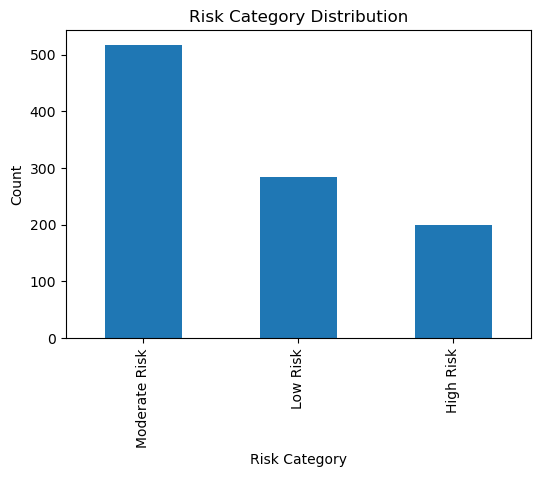

In [6]:
plt.figure(figsize=(6,4))

df["risk_category"].value_counts().plot(kind="bar")

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

In [7]:
df["worker_type"].value_counts()

worker_type
Delivery Partner     365
Ride Share Driver    306
Freelancer           229
Content Creator      100
Name: count, dtype: int64

In [8]:
df.groupby("risk_category")["financial_health_score"].mean()

risk_category
High Risk        40.025126
Low Risk         84.757042
Moderate Risk    62.787234
Name: financial_health_score, dtype: float64

In [9]:
df.groupby("risk_category")["monthly_income"].mean()

risk_category
High Risk        46912.567839
Low Risk         51630.221831
Moderate Risk    50523.756286
Name: monthly_income, dtype: float64

In [10]:
df.groupby("risk_category")["savings_ratio"].mean()

risk_category
High Risk        0.162211
Low Risk         0.242676
Moderate Risk    0.203482
Name: savings_ratio, dtype: float64

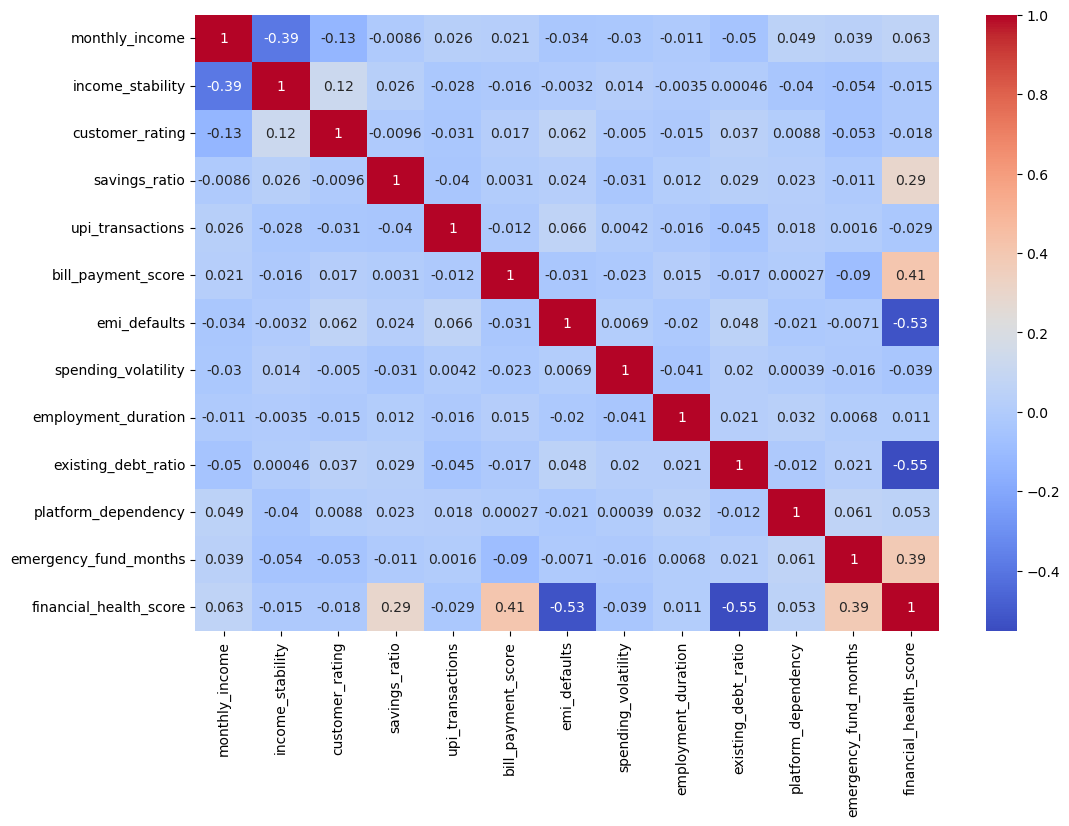

In [11]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [12]:
df.groupby("risk_category")["monthly_income"].mean()

risk_category
High Risk        46912.567839
Low Risk         51630.221831
Moderate Risk    50523.756286
Name: monthly_income, dtype: float64

In [13]:
df.groupby("risk_category")["existing_debt_ratio"].mean()

risk_category
High Risk        0.598090
Low Risk         0.251338
Moderate Risk    0.420000
Name: existing_debt_ratio, dtype: float64

In [14]:
pd.crosstab(
    df["worker_type"],
    df["risk_category"]
)

risk_category,High Risk,Low Risk,Moderate Risk
worker_type,,,
Content Creator,17,32,51
Delivery Partner,78,104,183
Freelancer,42,58,129
Ride Share Driver,62,90,154
